In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("/content/loan.csv")

In [3]:
df = df[['loan_amnt','term','int_rate','annual_inc',
         'emp_length','home_ownership','purpose','loan_status']]

In [4]:
df = df.dropna()

df = df[(df['loan_status'] == 'Fully Paid') |
        (df['loan_status'] == 'Charged Off')]

In [5]:
df['loan_status'] = df['loan_status'].replace({
    'Fully Paid': 0,
    'Charged Off': 1
})

df['term'] = df['term'].astype(str)
df['term'] = df['term'].str.replace(' months', '', regex=False)
df['term'] = pd.to_numeric(df['term'], errors='coerce')

df['int_rate'] = df['int_rate'].astype(str)
df['int_rate'] = df['int_rate'].str.replace('%', '', regex=False)
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

/tmp/ipykernel_18488/2049224936.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].replace({


In [6]:
print(df.describe())

          loan_amnt       term   int_rate     annual_inc  loan_status
count     72.000000  72.000000  72.000000      72.000000         72.0
mean   12279.861111  40.666667  13.523472   81587.472222          0.0
std     9362.911586   9.565195   5.548340   61254.077739          0.0
min     1000.000000  36.000000   7.020000   18000.000000          0.0
25%     5000.000000  36.000000   8.190000   50000.000000          0.0
50%    10000.000000  36.000000  12.980000   64000.000000          0.0
75%    20000.000000  36.000000  17.175000   93500.000000          0.0
max    40000.000000  60.000000  27.270000  450000.000000          0.0


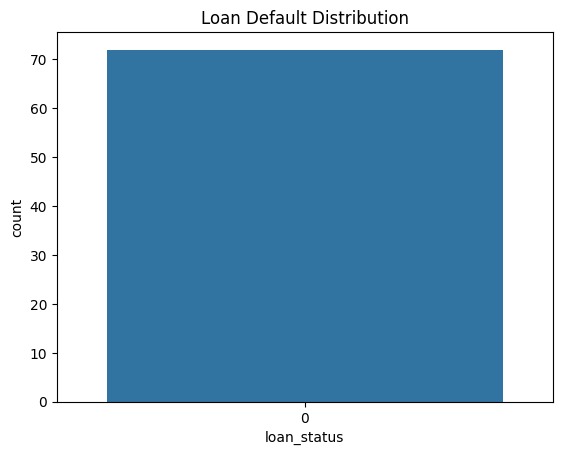

In [7]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Default Distribution")
plt.show()

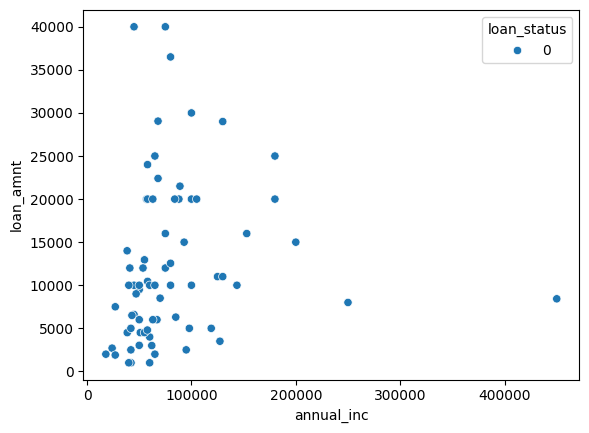

In [8]:
sns.scatterplot(x='annual_inc', y='loan_amnt',
                hue='loan_status', data=df)
plt.show()

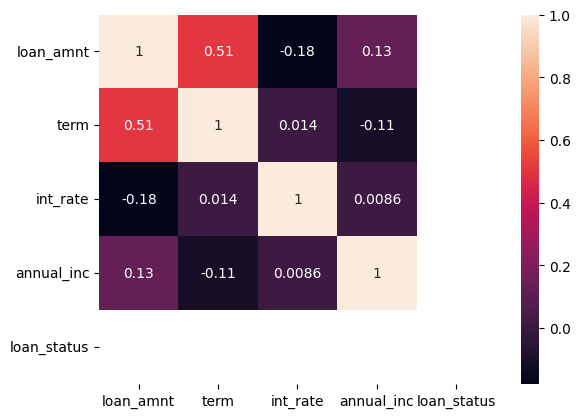

In [9]:
sns.heatmap(df[['loan_amnt','term','int_rate',
                'annual_inc','loan_status']].corr(),
            annot=True)
plt.show()

In [10]:
X = df[['annual_inc','int_rate','term']]
y = df['loan_amnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.3314437500910854


In [11]:
fig = px.scatter(df, x='annual_inc', y='loan_amnt',
                 color='loan_status',
                 title='Income vs Loan Amount')

fig.show()

In [12]:
print("Loan Default Prediction Completed")

Loan Default Prediction Completed
